# HR Employee Attrition Analysis


**Business Question:**  
Which employee segments are most at risk of attrition, and what combination of factors drives it?

**Tools:** Python · Pandas · Seaborn · Scikit-learn (K-Means, Logistic Regression)  
**Dashboard:** Power BI  
**Author:** Somto Ogene


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
BLUE = '#2E5090'
RED  = '#E74C3C'


DATA_PATH = r"WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset loaded: 1,470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Data Overview and Cleaning

In [2]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Constant columns add no value to analysis or ML
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped constant columns: {constant_cols}")
print(f"Clean shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Create derived columns
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)
df['OvertimeEncoded'] = (df['OverTime'] == 'Yes').astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65],
                         labels=['18-25','26-35','36-45','46-55','56-65'])

print(f"\nAttrition rate: {df['AttritionBinary'].mean()*100:.1f}% ({df['AttritionBinary'].sum()} of {len(df)})")
df.describe(include='all').T


Missing values: 0
Dropped constant columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Clean shape: 1,470 rows x 31 columns

Attrition rate: 16.1% (237 of 1470)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EnvironmentSatisfaction,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
Gender,1470,2,Male,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Attrition by Key Demographics

We start by understanding *who* is leaving. Broken down by department, job role, age group, gender, marital status, and overtime. Red bars = above the 16.1% company average.


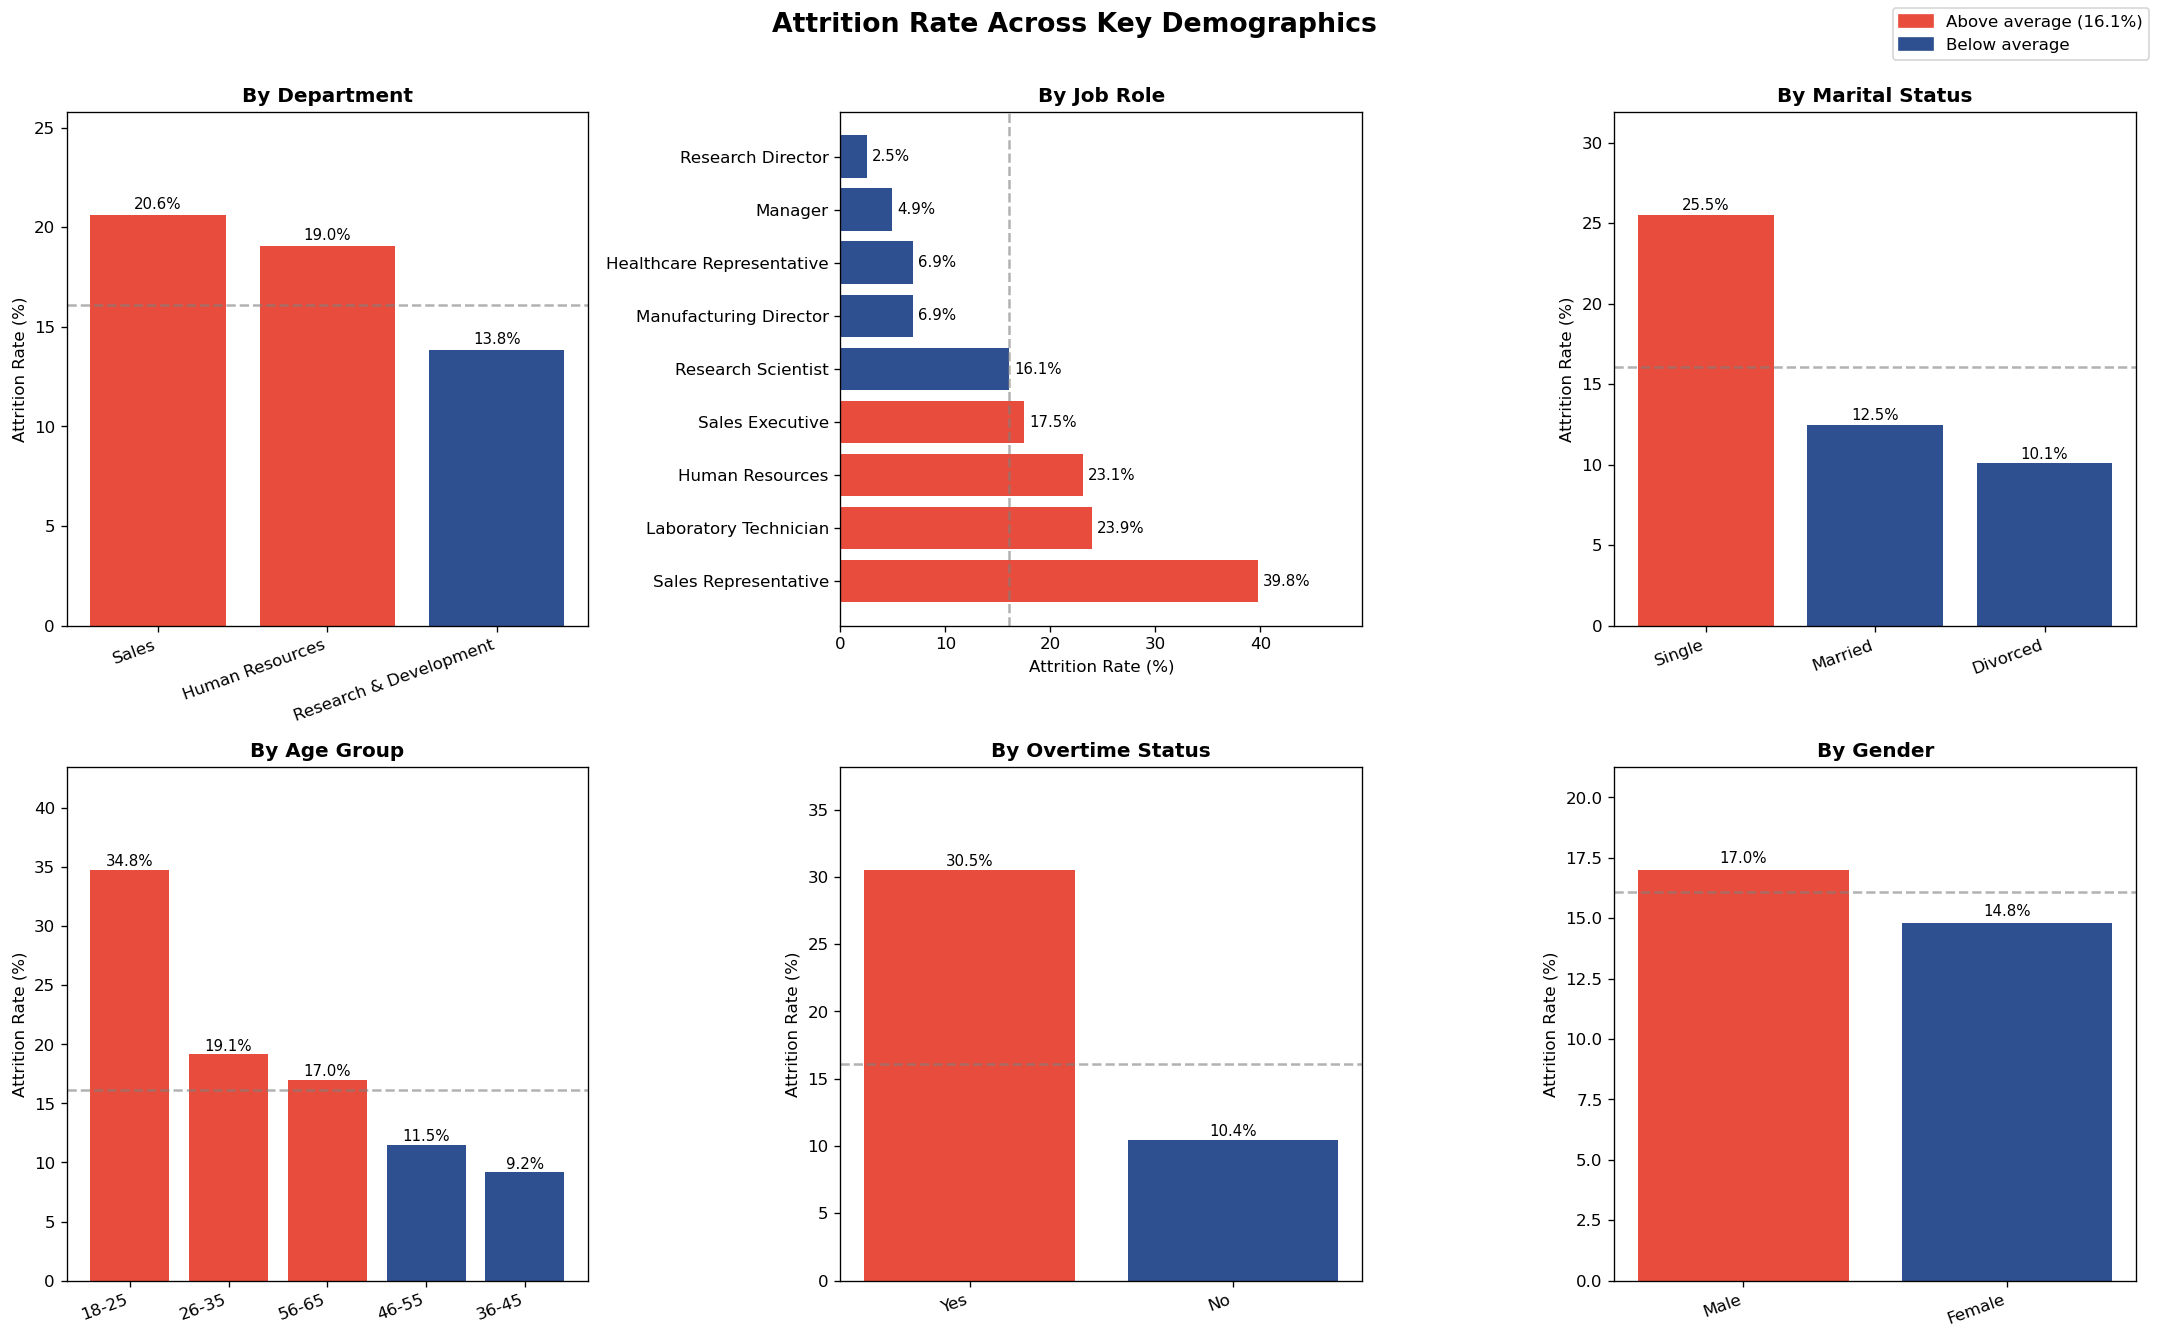

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Attrition Rate Across Key Demographics', fontsize=16, fontweight='bold', y=1.01)

def attrition_rate_bar(ax, col, title, horizontal=False):
    rates = df.groupby(col)['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
    colors = [RED if r > 16.1 else BLUE for r in rates]
    if horizontal:
        bars = ax.barh(rates.index, rates.values, color=colors)
        ax.set_xlabel('Attrition Rate (%)')
        for bar, val in zip(bars, rates.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
        ax.set_xlim(0, rates.max()*1.25)
        ax.axvline(x=16.1, color='gray', linestyle='--', alpha=0.6, label='Avg 16.1%')
    else:
        bars = ax.bar(rates.index, rates.values, color=colors)
        ax.set_ylabel('Attrition Rate (%)')
        for bar, val in zip(bars, rates.values):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%', ha='center', fontsize=9)
        ax.set_ylim(0, rates.max()*1.25)
        ax.set_xticklabels(rates.index, rotation=20, ha='right')
        ax.axhline(y=16.1, color='gray', linestyle='--', alpha=0.6, label='Avg 16.1%')
    ax.set_title(title, fontweight='bold')

attrition_rate_bar(axes[0,0], 'Department', 'By Department')
attrition_rate_bar(axes[0,1], 'JobRole', 'By Job Role', horizontal=True)
attrition_rate_bar(axes[0,2], 'MaritalStatus', 'By Marital Status')
attrition_rate_bar(axes[1,0], 'AgeGroup', 'By Age Group')
attrition_rate_bar(axes[1,1], 'OverTime', 'By Overtime Status')
attrition_rate_bar(axes[1,2], 'Gender', 'By Gender')

red_patch = mpatches.Patch(color=RED, label='Above average (16.1%)')
blue_patch = mpatches.Patch(color=BLUE, label='Below average')
fig.legend(handles=[red_patch, blue_patch], loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('attrition_demographics.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Satisfaction Scores and Compensation vs Attrition

IBM encoded satisfaction on a 1–4 scale. Leavers consistently skew toward Level 1–2 scores across all satisfaction dimensions, and earn less on average.


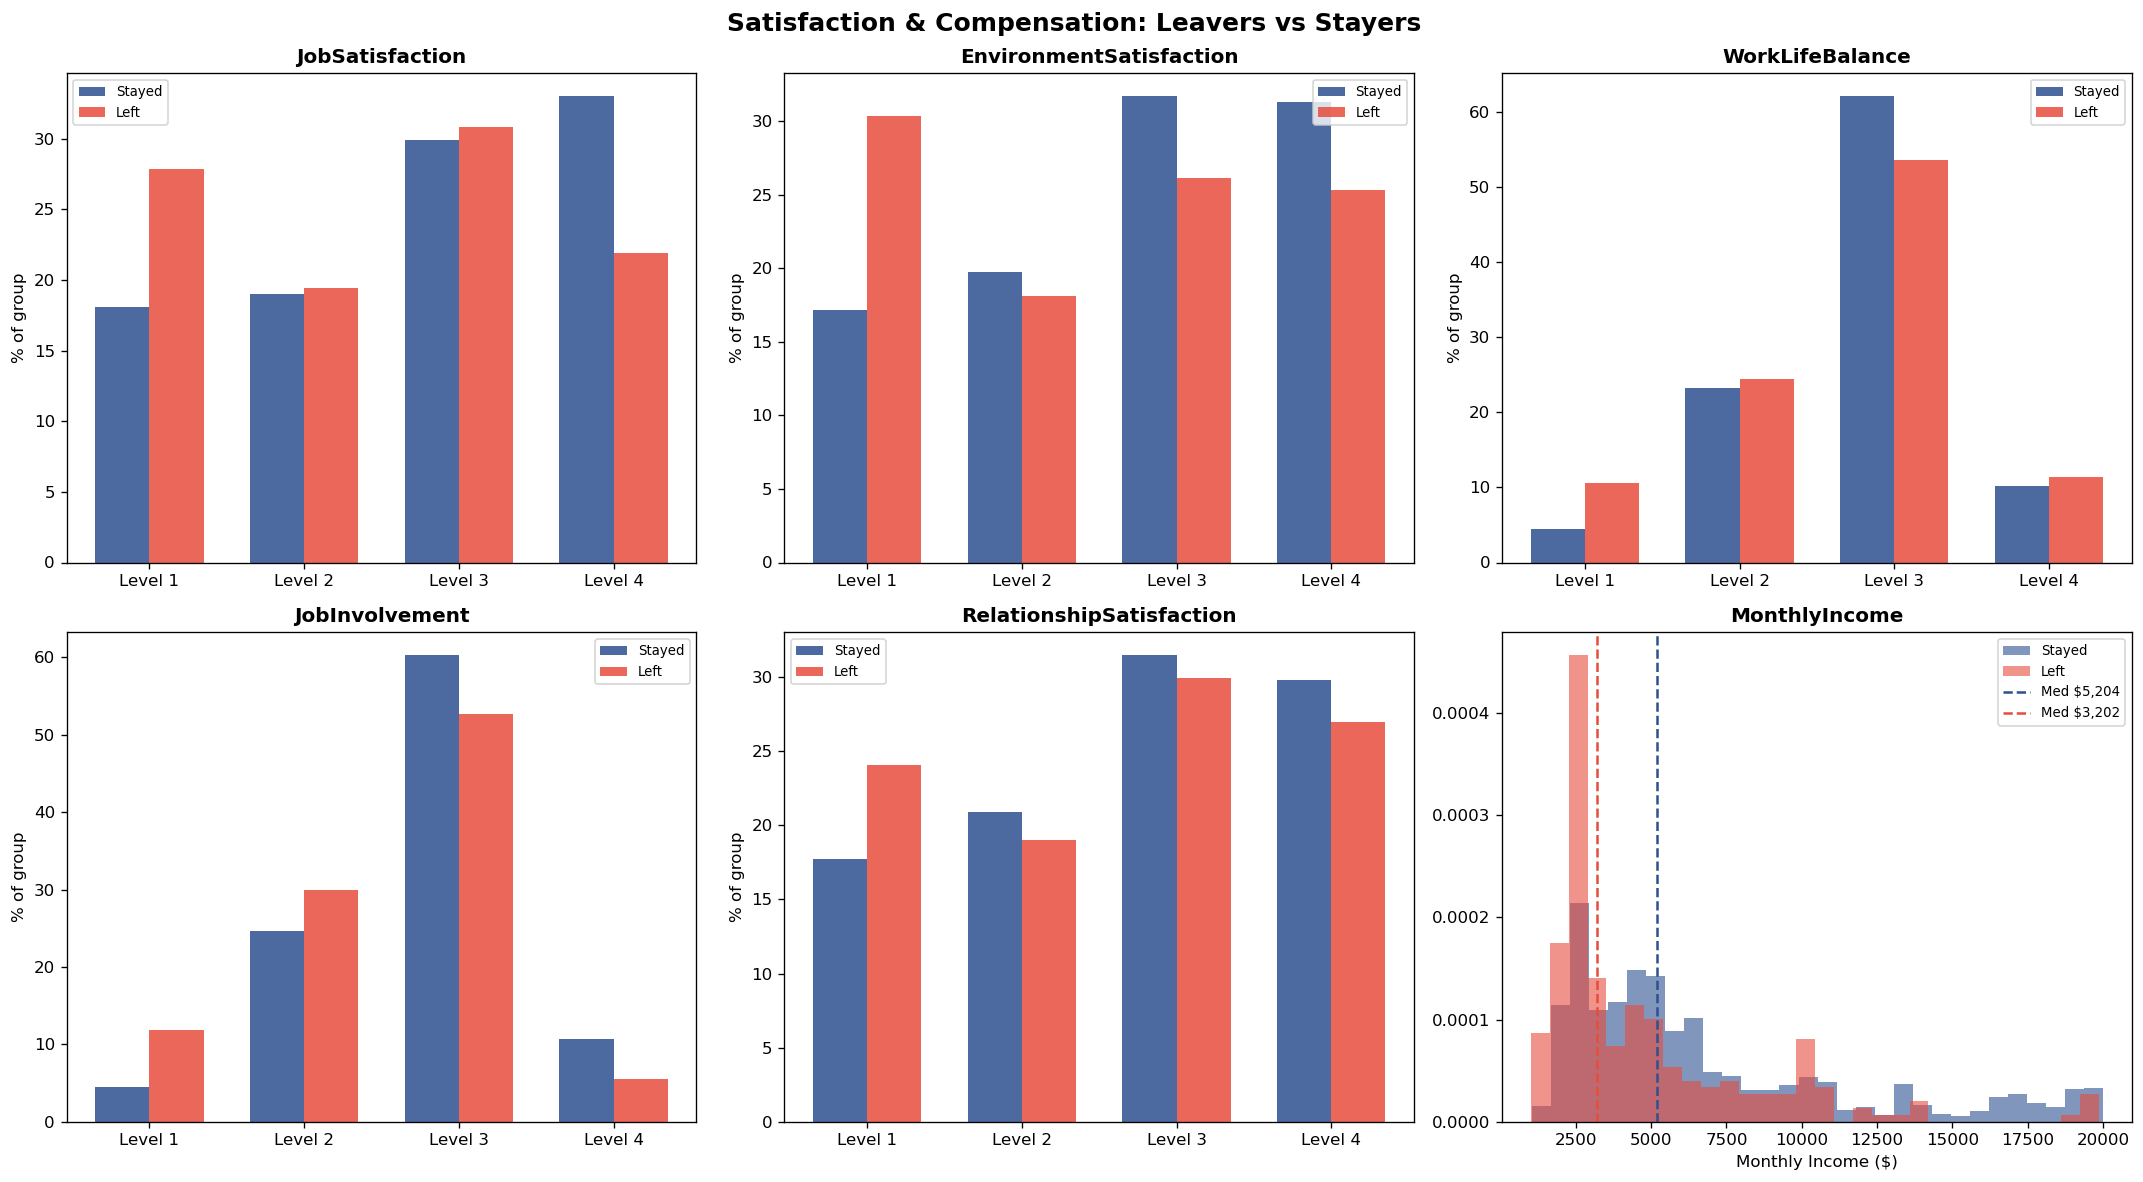

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Satisfaction & Compensation: Leavers vs Stayers', fontsize=15, fontweight='bold')

satisfaction_cols = ['JobSatisfaction','EnvironmentSatisfaction','WorkLifeBalance',
                     'JobInvolvement','RelationshipSatisfaction','MonthlyIncome']

for ax, col in zip(axes.flat, satisfaction_cols):
    stayers = df[df['Attrition']=='No'][col]
    leavers  = df[df['Attrition']=='Yes'][col]
    if col == 'MonthlyIncome':
        ax.hist(stayers, bins=30, alpha=0.6, color=BLUE, label='Stayed', density=True)
        ax.hist(leavers, bins=30, alpha=0.6, color=RED, label='Left', density=True)
        ax.axvline(stayers.median(), color=BLUE, linestyle='--', linewidth=1.5, label=f'Med ${stayers.median():,.0f}')
        ax.axvline(leavers.median(), color=RED, linestyle='--', linewidth=1.5, label=f'Med ${leavers.median():,.0f}')
        ax.set_xlabel('Monthly Income ($)')
    else:
        vals = sorted(df[col].unique()); x = np.arange(len(vals)); w = 0.35
        stayed_pct = [df[(df['Attrition']=='No') & (df[col]==v)].shape[0]/df[df['Attrition']=='No'].shape[0]*100 for v in vals]
        left_pct   = [df[(df['Attrition']=='Yes') & (df[col]==v)].shape[0]/df[df['Attrition']=='Yes'].shape[0]*100 for v in vals]
        ax.bar(x-w/2, stayed_pct, w, label='Stayed', color=BLUE, alpha=0.85)
        ax.bar(x+w/2, left_pct, w, label='Left', color=RED, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([f'Level {v}' for v in vals])
        ax.set_ylabel('% of group')
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('attrition_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Correlation Heatmap

Top correlates with attrition (from the data):  
**Positive (increases risk):** OvertimeEncoded (+0.25)  
**Negative (reduces risk):** TotalWorkingYears (−0.17), JobLevel (−0.17), MonthlyIncome (−0.16), Age (−0.16)


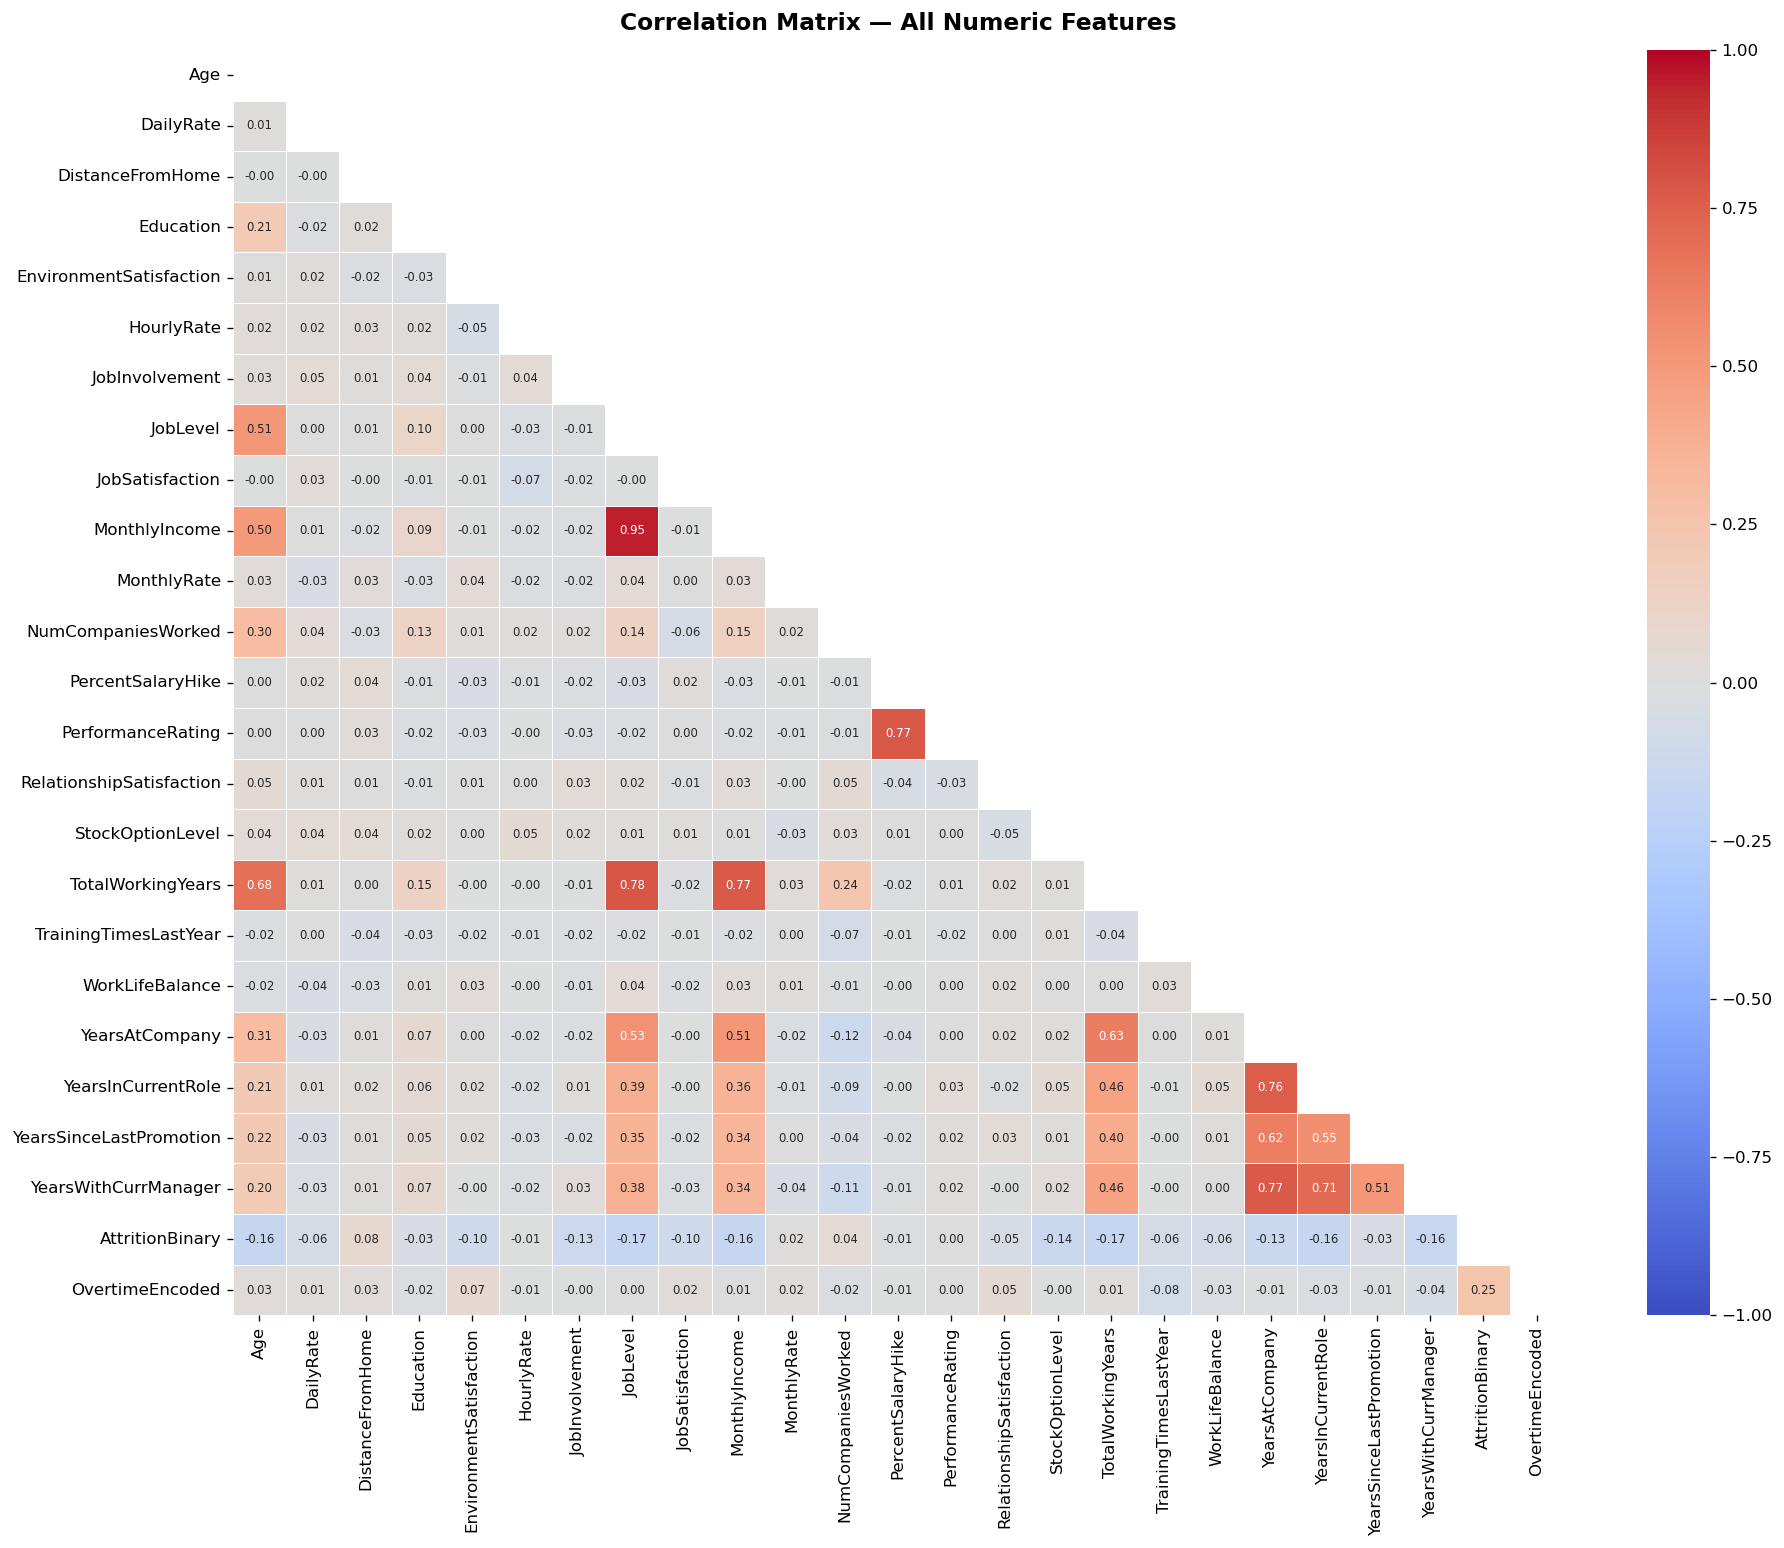

Top 10 features correlated with Attrition:
OvertimeEncoded         0.246118
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
Name: AttritionBinary, dtype: float64


In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Numeric Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 10 features correlated with Attrition:")
print(corr['AttritionBinary'].drop('AttritionBinary').sort_values(key=abs, ascending=False).head(10))


## 6. K-Means Employee Segmentation

We cluster employees into 4 distinct profiles using 11 features most associated with attrition.  
The elbow plot confirms k=4 is the natural break point.

**Resulting segments:**
| Cluster | Label | n | Attrition Rate |
|---|---|---|---|
| 0 | Stable Senior | 215 | 7.0% |
| 1 | Loyal Mid-Career | 415 | 7.2% |
| 2 | Burnt-Out & Overworked | 351 | **34.2%** |
| 3 | At-Risk Mid-Level | 489 | 14.7% |


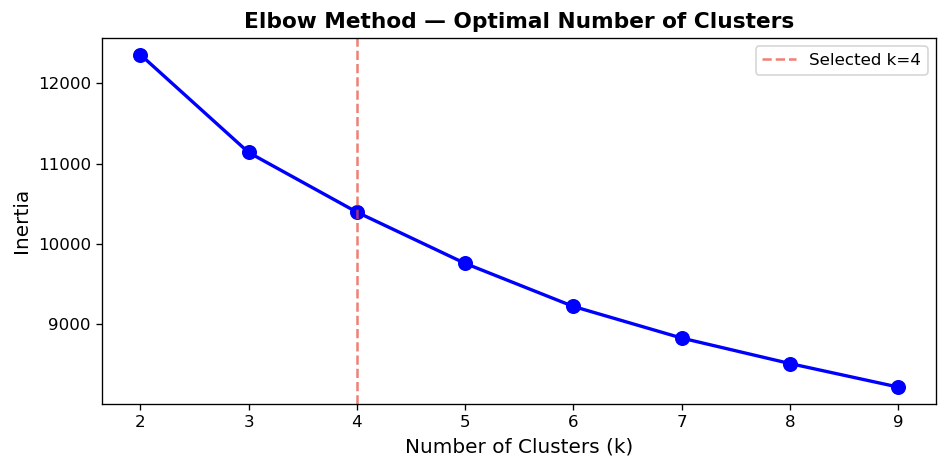

                        Count AttritionRate  AvgAge  AvgIncome  AvgJobSatisfaction OvertimePct  AvgYearsAtCompany
ClusterLabel                                                                                                     
At-Risk Mid-Level         489         14.7%    31.1     3614.3                 2.6          0%                3.8
Burnt-Out & Overworked    351         34.2%    35.3     4938.6                 2.8        100%                5.3
Loyal Mid-Career          415          7.2%    39.6     6494.9                 2.8          0%                8.0
Stable Senior             215          7.0%    47.6    15642.3                 2.7         30%               15.1


In [6]:
cluster_features = ['Age','MonthlyIncome','JobSatisfaction','EnvironmentSatisfaction',
                    'WorkLifeBalance','YearsAtCompany','YearsSinceLastPromotion',
                    'JobLevel','TotalWorkingYears','JobInvolvement','OvertimeEncoded']

X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow plot
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 10), inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color=RED, linestyle='--', alpha=0.7, label='Selected k=4')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', bbox_inches='tight', dpi=150)
plt.show()

# Fit final model
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# Hardcoded labels based on observed cluster profiles
CLUSTER_LABELS = {0: 'Stable Senior', 1: 'Loyal Mid-Career',
                  2: 'Burnt-Out & Overworked', 3: 'At-Risk Mid-Level'}
df['ClusterLabel'] = df['Cluster'].map(CLUSTER_LABELS)

profile = df.groupby('ClusterLabel').agg(
    Count=('Cluster','count'),
    AttritionRate=('AttritionBinary', lambda x: f"{x.mean()*100:.1f}%"),
    AvgAge=('Age','mean'),
    AvgIncome=('MonthlyIncome','mean'),
    AvgJobSatisfaction=('JobSatisfaction','mean'),
    OvertimePct=('OvertimeEncoded', lambda x: f"{x.mean()*100:.0f}%"),
    AvgYearsAtCompany=('YearsAtCompany','mean')
).round(1)
print(profile.to_string())


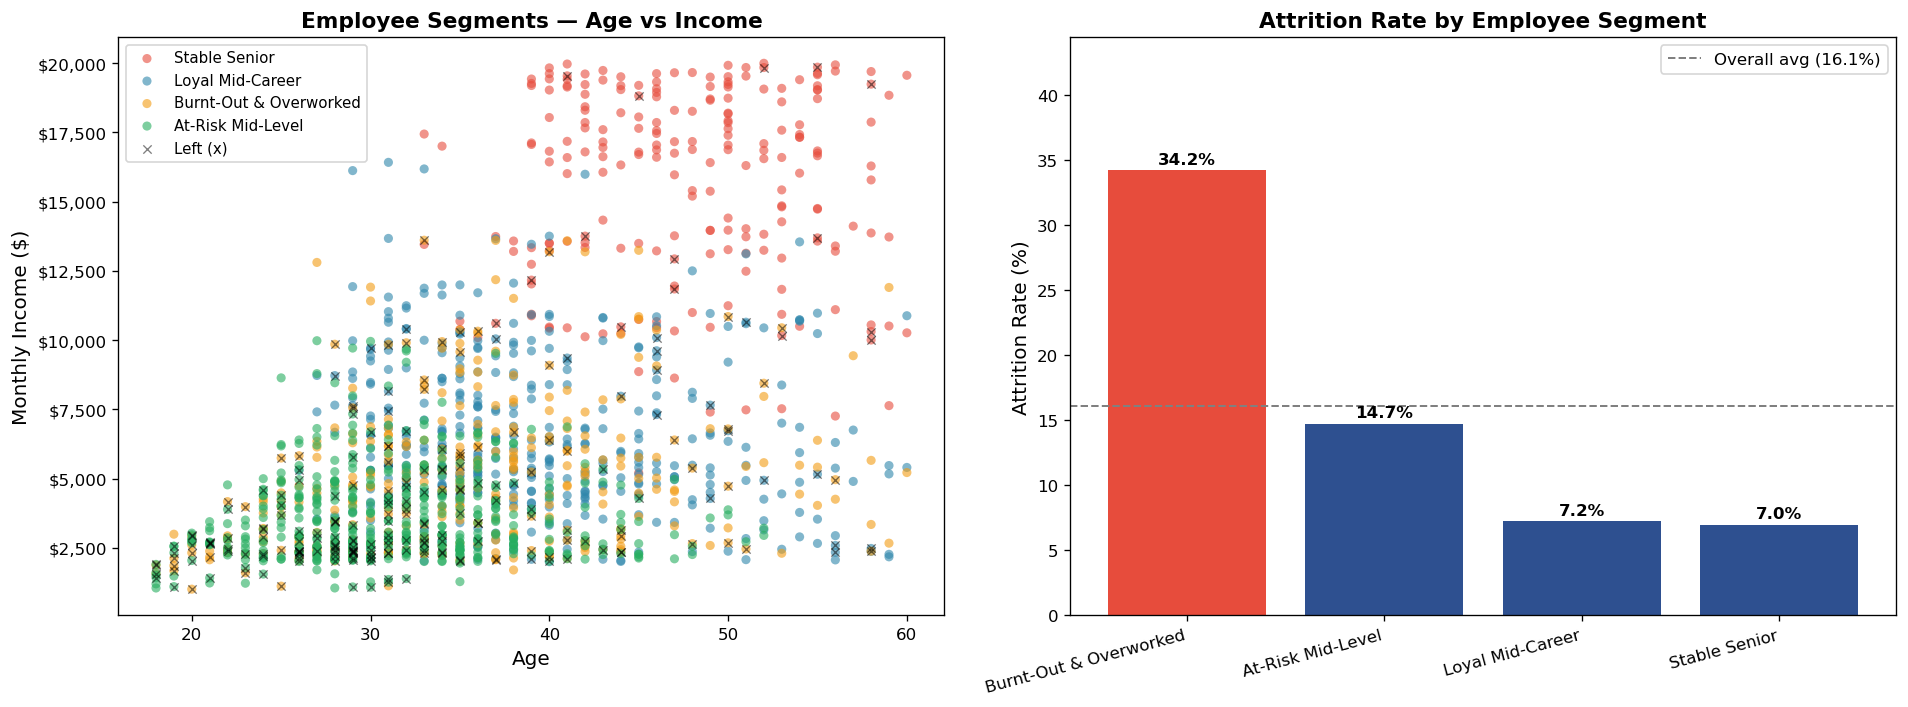

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_cluster = ['#E74C3C','#2E86AB','#F39C12','#27AE60']
cluster_color_map = {CLUSTER_LABELS[i]: colors_cluster[i] for i in range(4)}

for c in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster']==c]
    axes[0].scatter(sub['Age'], sub['MonthlyIncome'],
                    c=colors_cluster[c], label=CLUSTER_LABELS[c], alpha=0.6, s=30, edgecolors='none')
attritors = df[df['Attrition']=='Yes']
axes[0].scatter(attritors['Age'], attritors['MonthlyIncome'],
                marker='x', c='black', s=25, linewidths=0.8, alpha=0.5, label='Left (x)')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Monthly Income ($)', fontsize=12)
axes[0].set_title('Employee Segments — Age vs Income', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

cluster_order = df.groupby('ClusterLabel')['AttritionBinary'].mean().sort_values(ascending=False)
bar_colors = [RED if r > 0.161 else BLUE for r in cluster_order.values]
bars = axes[1].bar(cluster_order.index, cluster_order.values*100, color=bar_colors)
axes[1].axhline(y=16.1, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (16.1%)')
axes[1].set_ylabel('Attrition Rate (%)', fontsize=12)
axes[1].set_title('Attrition Rate by Employee Segment', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(cluster_order.index, rotation=15, ha='right')
axes[1].legend()
for bar, val in zip(bars, cluster_order.values*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, cluster_order.max()*100*1.3)
plt.tight_layout()
plt.savefig('cluster_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Logistic Regression.
## Top Attrition Drivers

A logistic regression model trained on all numeric features (balanced class weights to handle the 84/16 class imbalance).  

**Model performance:** ROC-AUC = 0.81. strong for an interpretable baseline.  
Coefficients are standardised, so they are directly comparable across features.


In [8]:
df_model = df.copy()
cat_cols = [c for c in df_model.select_dtypes(include='object').columns
            if c not in ['Attrition','ClusterLabel','AgeGroup']]
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

feature_cols = [c for c in df_model.select_dtypes(include='number').columns
                if c not in ['AttritionBinary','Cluster','OvertimeEncoded']]
X = df_model[feature_cols]
y = df_model['AttritionBinary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc2 = StandardScaler()
X_train_sc = sc2.fit_transform(X_train)
X_test_sc  = sc2.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, C=0.5)
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)
y_prob = lr.predict_proba(X_test_sc)[:,1]

print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


              precision    recall  f1-score   support

      Stayed       0.94      0.75      0.84       247
        Left       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294

ROC-AUC: 0.8072


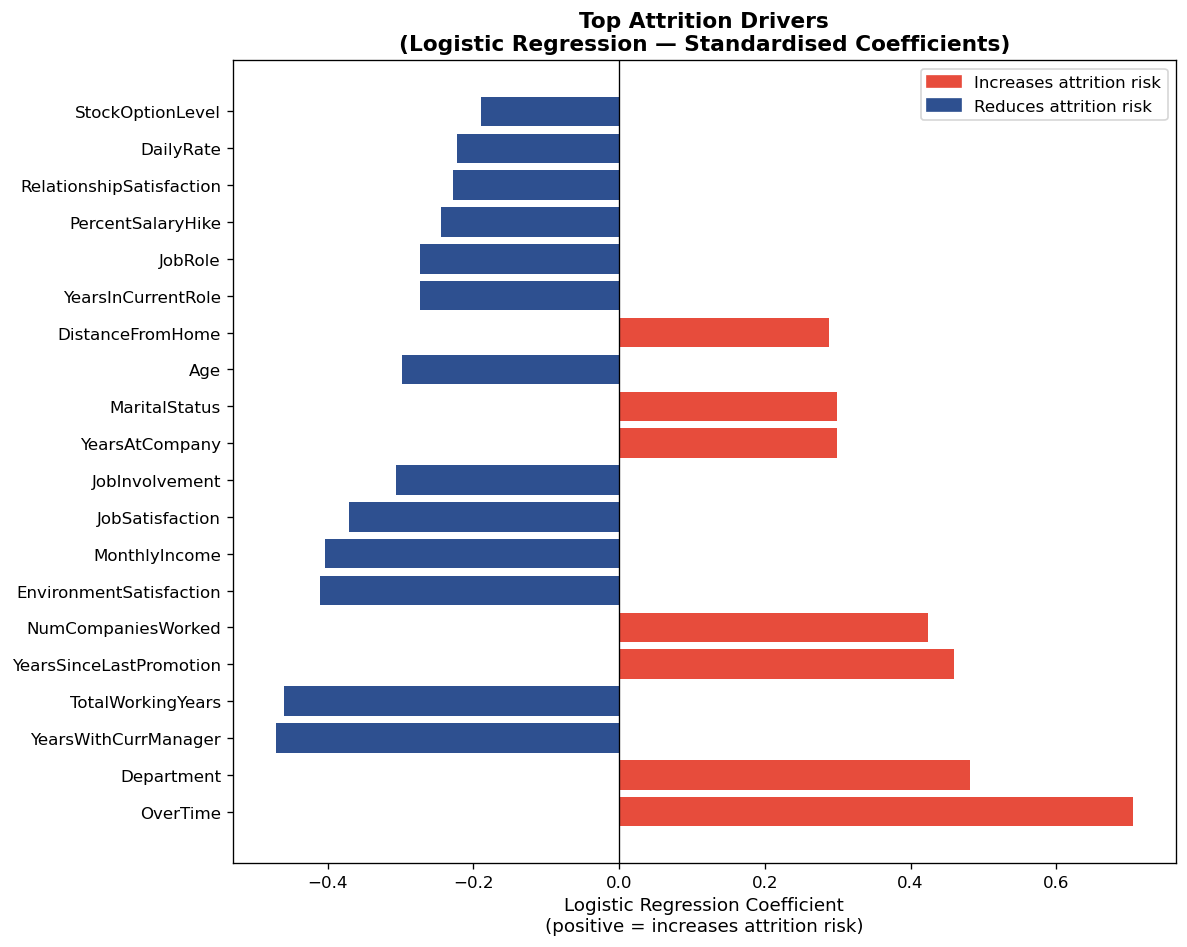

In [9]:
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(20)
coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: 'Increases Risk' if x > 0 else 'Reduces Risk')

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RED if d == 'Increases Risk' else BLUE for d in coef_df['Direction']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient\n(positive = increases attrition risk)', fontsize=11)
ax.set_title('Top Attrition Drivers\n(Logistic Regression — Standardised Coefficients)', fontsize=13, fontweight='bold')
red_patch = mpatches.Patch(color=RED, label='Increases attrition risk')
blue_patch = mpatches.Patch(color=BLUE, label='Reduces attrition risk')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Deep Dive (Overtime × Job Satisfaction Interaction)

Overtime alone raises attrition to ~31%. But when combined with low job satisfaction (Level 1), attrition among overtime workers hits ~44%, nearly 3× the company average.


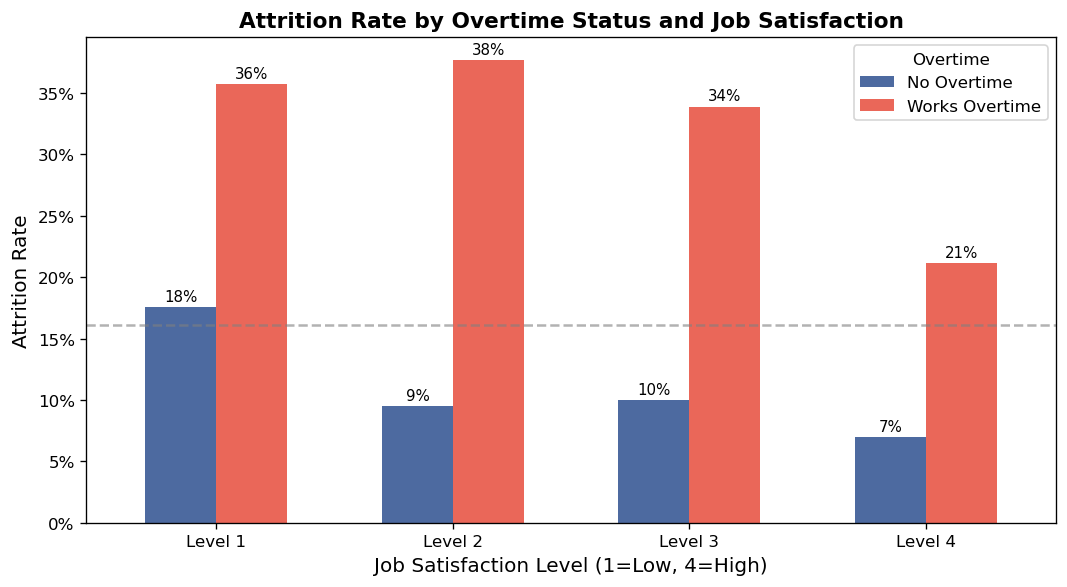

In [10]:
pivot = df.groupby(['OverTime','JobSatisfaction'])['AttritionBinary'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
pivot.T.plot(kind='bar', ax=ax, color=[BLUE, RED], alpha=0.85, width=0.6)
ax.set_xlabel('Job Satisfaction Level (1=Low, 4=High)', fontsize=12)
ax.set_ylabel('Attrition Rate', fontsize=12)
ax.set_title('Attrition Rate by Overtime Status and Job Satisfaction', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Overtime', labels=['No Overtime','Works Overtime'])
ax.set_xticklabels(['Level 1','Level 2','Level 3','Level 4'], rotation=0)
ax.axhline(y=0.161, color='gray', linestyle='--', alpha=0.6, label='Overall avg')
for container in ax.containers:
    ax.bar_label(container, fmt='{:.0%}', fontsize=9, padding=2)
plt.tight_layout()
plt.savefig('overtime_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Key Findings and Recommendations

| Finding | Metric | Implication |
|---|---|---|
| Overall attrition | 16.1% (237 of 1,470) | ~1 in 6 employees left |
| Highest-risk role | Sales Representative | ~40% attrition rate |
| Overtime workers | 31% leave vs 10% non-OT | 3x higher risk |
| Age group most at risk | 18-25 | Early-career flight risk |
| Single employees | Highest among marital groups | No anchoring effect |
| OT + Satisfaction Level 1 | ~44% attrition | Compounding risk |
| Top ML predictor | OverTime | ROC-AUC 0.81 confirms |
| Highest-risk cluster | Burnt-Out & Overworked (34.2%) | Urgent HR intervention |

### Recommendations

1. **Overtime policy** — cap mandatory overtime; introduce compensatory leave for Sales and HR
2. **Career pathing for 18-25 cohort** — mentorship programmes, transparent promotion timelines
3. **Satisfaction pulse surveys** — act immediately on Level 1 and 2 scores before they escalate
4. **Income benchmarking** — Sales Reps earn less yet face the highest departure rate
5. **Segment-based retention plans** — the 4 clusters need different interventions, not one-size-fits-all HR policy


## 10. Export Cleaned Dataset for Power BI

In [11]:
summary_cols = ['Age','AgeGroup','Department','JobRole','Gender','MaritalStatus',
                'OverTime','MonthlyIncome','JobSatisfaction','EnvironmentSatisfaction',
                'WorkLifeBalance','JobInvolvement','YearsAtCompany','YearsSinceLastPromotion',
                'TotalWorkingYears','JobLevel','BusinessTravel','Attrition','AttritionBinary',
                'Cluster','ClusterLabel']

df[summary_cols].to_csv('HR_Attrition_Cleaned.csv', index=False)
print(f"Exported HR_Attrition_Cleaned.csv — {df.shape[0]:,} rows x {len(summary_cols)} columns")
print("This file is ready to load into Power BI.")


Exported HR_Attrition_Cleaned.csv — 1,470 rows x 21 columns
This file is ready to load into Power BI.


---
*Analysis by Somto Ogene | Portfolio Project 2 | Python · Pandas · Scikit-learn · Power BI*